# Análisis y Predicción de Precios del Oro con Redes Neuronales

## Proyecto: Regresión con TensorFlow/Keras

Este proyecto es una demostracion de los conceptos de underfitting, overfitting y modelo balanceado mediante el análisis de datos históricos de precios del oro.

### Estructura del Proyecto:
- Commit 1: Carga y Preprocesamiento de Datos
- Commit 2: Modelo Subentrenado (Underfitting)
- Commit 3: Modelo Sobreentrenado (Overfitting)
- Commit 4: Modelo Balanceado y Comparaciones


##  Importación de Librerías

Importamos todas las librerías necesarias para el análisis y modelado.

In [114]:
# Importaciones básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn para preprocesamiento
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración de estilo para gráficas profesionales
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("Librerías importadas correctamente")
print(f"TensorFlow versión: {tf.__version__}")

Librerías importadas correctamente
TensorFlow versión: 2.21.0


#  Commit 1: Carga y Preprocesamiento de Datos

En esta sección:
1. Cargamos el dataset de precios mensuales del oro
2. Exploramos la estructura de los datos
3. Transformamos las fechas a valores numéricos secuenciales
4. Normalizamos los datos para mejorar la convergencia del modelo
5. Dividimos en conjuntos de entrenamiento (80%) y prueba (20%)

### Carga del Dataset

In [115]:
# Cargar el archivo CSV
df = pd.read_csv('.devcontainer/monthly_gold_prices.csv')

print("Primeras filas del dataset:")
print(df.head(10))
print("\n" + "="*60)
print(f"\n Dimensiones del dataset: {df.shape}")
print(f"   - Total de registros mensuales: {len(df)}")
print(f"   - Período: {df['Date'].iloc[0]} hasta {df['Date'].iloc[-1]}")

Primeras filas del dataset:
      Date  Price
0  1833-01  18.93
1  1833-02  18.93
2  1833-03  18.93
3  1833-04  18.93
4  1833-05  18.93
5  1833-06  18.93
6  1833-07  18.93
7  1833-08  18.93
8  1833-09  18.93
9  1833-10  18.93


 Dimensiones del dataset: (2318, 2)
   - Total de registros mensuales: 2318
   - Período: 1833-01 hasta 2026-02


### Exploración Inicial de Datos

In [116]:
# Información general del dataset
print("ℹ Información del Dataset:")
print(df.info())
print("\n" + "="*60)

# Estadísticas descriptivas
print("\n Estadísticas Descriptivas:")
print(df.describe())
print("\n" + "="*60)

# Verificar valores nulos
print("\n Verificación de Valores Nulos:")
print(df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("No hay valores nulos en el dataset")
else:
    print("Se encontraron valores nulos que deben ser tratados")

ℹ Información del Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2318 non-null   str    
 1   Price   2318 non-null   float64
dtypes: float64(1), str(1)
memory usage: 36.3 KB
None


 Estadísticas Descriptivas:
             Price
count  2318.000000
mean    232.232352
std     508.694544
min      17.060000
25%      18.940000
50%      20.680000
75%     176.300000
max    5019.970000


 Verificación de Valores Nulos:
Date     0
Price    0
dtype: int64
No hay valores nulos en el dataset


### Transformación de Fechas a Valores Numéricos

Las redes neuronales necesitan entradas numéricas. Convertimos las fechas a un índice secuencial (0, 1, 2, ...) que representa el número de meses desde el inicio del dataset.

In [117]:
# Crear índice numérico secuencial
# Cada valor representa el número de meses desde el inicio
df['Month_Index'] = range(len(df))

print("Transformación de fechas completada:")
print(df[['Date', 'Month_Index', 'Price']].head(10))
print(f"\nRango de Month_Index: {df['Month_Index'].min()} a {df['Month_Index'].max()}")

Transformación de fechas completada:
      Date  Month_Index  Price
0  1833-01            0  18.93
1  1833-02            1  18.93
2  1833-03            2  18.93
3  1833-04            3  18.93
4  1833-05            4  18.93
5  1833-06            5  18.93
6  1833-07            6  18.93
7  1833-08            7  18.93
8  1833-09            8  18.93
9  1833-10            9  18.93

Rango de Month_Index: 0 a 2317


### Visualización Inicial de los Datos

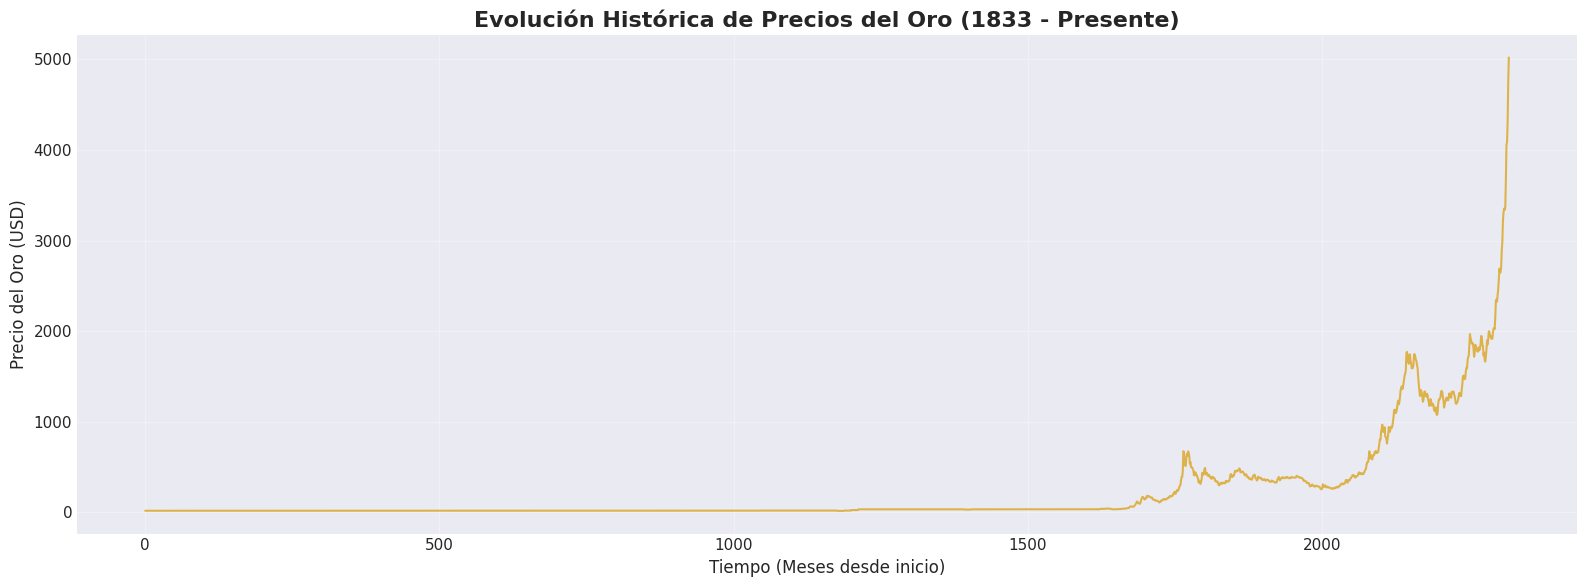

Observaciones:
   - Precio mínimo: $17.06
   - Precio máximo: $5019.97
   - Precio promedio: $232.23
   - Desviación estándar: $508.69


In [118]:
# Gráfica de precios del oro a lo largo del tiempo
plt.figure(figsize=(16, 6))
plt.plot(df['Month_Index'], df['Price'], color='goldenrod', linewidth=1.5, alpha=0.8)
plt.title('Evolución Histórica de Precios del Oro (1833 - Presente)', fontsize=16, fontweight='bold')
plt.xlabel('Tiempo (Meses desde inicio)', fontsize=12)
plt.ylabel('Precio del Oro (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observaciones:")
print(f"   - Precio mínimo: ${df['Price'].min():.2f}")
print(f"   - Precio máximo: ${df['Price'].max():.2f}")
print(f"   - Precio promedio: ${df['Price'].mean():.2f}")
print(f"   - Desviación estándar: ${df['Price'].std():.2f}")

### Normalización de Datos

- Mejora la convergencia del algoritmo de optimización
- Evita que características con valores grandes dominen el aprendizaje
- Acelera el entrenamiento y mejora la estabilidad numérica

In [119]:
# Preparar datos para normalización
X = df['Month_Index'].values.reshape(-1, 1)  # Variable independiente (tiempo)
y = df['Price'].values.reshape(-1, 1)        # Variable dependiente (precio)

# Crear escaladores
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Normalizar a rango [0, 1]
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print("Normalización completada:")
print(f"\nRango original de X: [{X.min():.2f}, {X.max():.2f}]")
print(f"Rango normalizado de X: [{X_scaled.min():.4f}, {X_scaled.max():.4f}]")
print(f"\nRango original de y: [{y.min():.2f}, {y.max():.2f}]")
print(f"Rango normalizado de y: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")

Normalización completada:

Rango original de X: [0.00, 2317.00]
Rango normalizado de X: [0.0000, 1.0000]

Rango original de y: [17.06, 5019.97]
Rango normalizado de y: [0.0000, 1.0000]


### División en Conjuntos de Entrenamiento y Prueba

- **80%** para entrenamiento: el modelo aprende de estos datos
- **20%** para prueba: evaluamos la capacidad de generalización

In [120]:
# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False
)

print("División de datos completada:")
print(f"\nConjunto de entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Conjunto de prueba: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nForma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

División de datos completada:

Conjunto de entrenamiento: 1854 muestras (80.0%)
Conjunto de prueba: 464 muestras (20.0%)

Forma de X_train: (1854, 1)
Forma de y_train: (1854, 1)
Forma de X_test: (464, 1)
Forma de y_test: (464, 1)


### Visualización de la División Train/Test

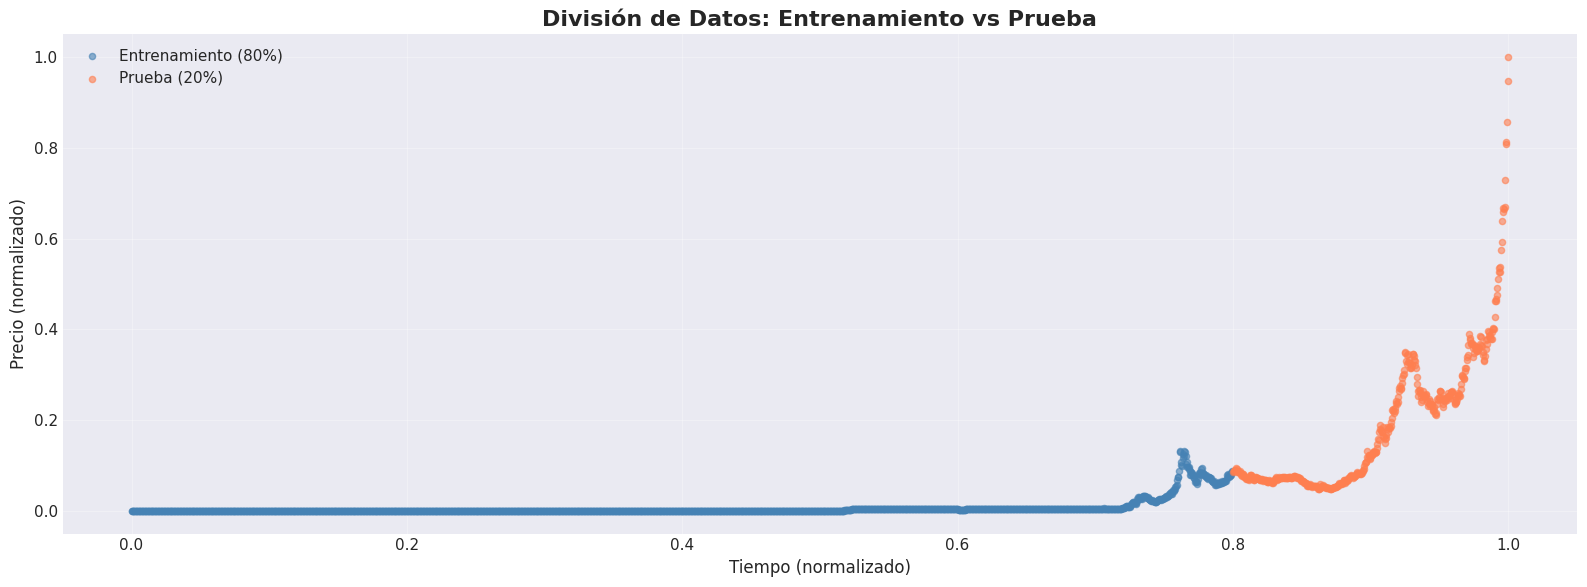

In [121]:
# Visualizar la división de datos
plt.figure(figsize=(16, 6))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.6, s=20, label='Entrenamiento (80%)')
plt.scatter(X_test, y_test, color='coral', alpha=0.6, s=20, label='Prueba (20%)')
plt.title('División de Datos: Entrenamiento vs Prueba', fontsize=16, fontweight='bold')
plt.xlabel('Tiempo (normalizado)', fontsize=12)
plt.ylabel('Precio (normalizado)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Commit 2: Modelo Subentrenado (Underfitting)

## ¿Qué es el Underfitting?

El **underfitting** ocurre cuando un modelo es demasiado simple para capturar los patrones subyacentes en los datos.

### Características:
- **Capacidad insuficiente**: pocas capas o neuronas
- **Entrenamiento limitado**: pocas epochs
- **Alto error**: tanto en entrenamiento como en validación
- **Predicciones pobres**: no sigue la tendencia de los datos

### En este ejemplo:
- Red neuronal con **1 capa oculta** de **3 neuronas**
- Solo **15 epochs** de entrenamiento
- Modelo demasiado simple para capturar la tendencia compleja del precio del oro

In [122]:
# Crear modelo con capacidad insuficiente
modelo_underfitting = Sequential([
    Dense(3, activation='relu', input_shape=(1,), name='capa_oculta'),
    Dense(1, name='capa_salida')
], name='Modelo_Underfitting')

# Compilar el modelo
modelo_underfitting.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Arquitectura del Modelo Subentrenado:")
modelo_underfitting.summary()
print("\nEste modelo tiene muy pocos parámetros para capturar patrones complejos")

Arquitectura del Modelo Subentrenado:


Model: "Modelo_Underfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)             │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)


Este modelo tiene muy pocos parámetros para capturar patrones complejos


### Entrenamiento del Modelo Subentrenado

In [123]:
# Entrenar con pocas epochs
print("Entrenando modelo subentrenado...")

history_underfitting = modelo_underfitting.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Entrenamiento completado")
print(f"\nÚltima epochs - Loss (entrenamiento): {history_underfitting.history['loss'][-1]:.6f}")
print(f"Última epochs - Loss (validación): {history_underfitting.history['val_loss'][-1]:.6f}")

Entrenando modelo subentrenado...
Entrenamiento completado

Última epochs - Loss (entrenamiento): 0.007354
Última epochs - Loss (validación): 0.061628


### Gráfica de Pérdida (Loss) durante el Entrenamiento

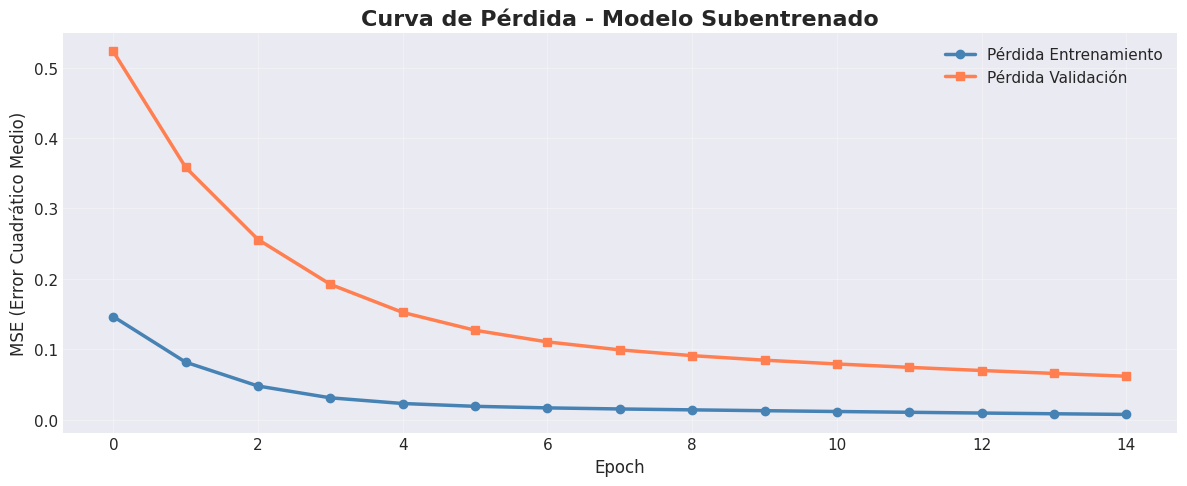

Observación: Ambas curvas permanecen altas, indicando que el modelo no logra aprender adecuadamente los patrones de los datos.


In [124]:
# Visualizar curva de pérdida
plt.figure(figsize=(12, 5))

plt.plot(history_underfitting.history['loss'], 
         color='steelblue', linewidth=2.5, marker='o', label='Pérdida Entrenamiento')
plt.plot(history_underfitting.history['val_loss'], 
         color='coral', linewidth=2.5, marker='s', label='Pérdida Validación')

plt.title('Curva de Pérdida - Modelo Subentrenado', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE (Error Cuadrático Medio)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observación: Ambas curvas permanecen altas, indicando que el modelo no logra aprender adecuadamente los patrones de los datos.")

### Predicciones y Evaluación

In [125]:
# Realizar predicciones
y_pred_under_train = modelo_underfitting.predict(X_train, verbose=0)
y_pred_under_test = modelo_underfitting.predict(X_test, verbose=0)

# Calcular métricas
mse_train_under = mean_squared_error(y_train, y_pred_under_train)
mae_train_under = mean_absolute_error(y_train, y_pred_under_train)
mse_test_under = mean_squared_error(y_test, y_pred_under_test)
mae_test_under = mean_absolute_error(y_test, y_pred_under_test)

print("Métricas del Modelo Subentrenado:")
print("="*50)
print(f"\nEntrenamiento:")
print(f"  - MSE: {mse_train_under:.6f}")
print(f"  - MAE: {mae_train_under:.6f}")
print(f"\nPrueba:")
print(f"  - MSE: {mse_test_under:.6f}")
print(f"  - MAE: {mae_test_under:.6f}")
print("\nLos errores altos indican underfitting")

Métricas del Modelo Subentrenado:

Entrenamiento:
  - MSE: 0.017828
  - MAE: 0.108426

Prueba:
  - MSE: 0.308907
  - MAE: 0.523119

Los errores altos indican underfitting


### Visualización de Predicciones vs Datos Reales

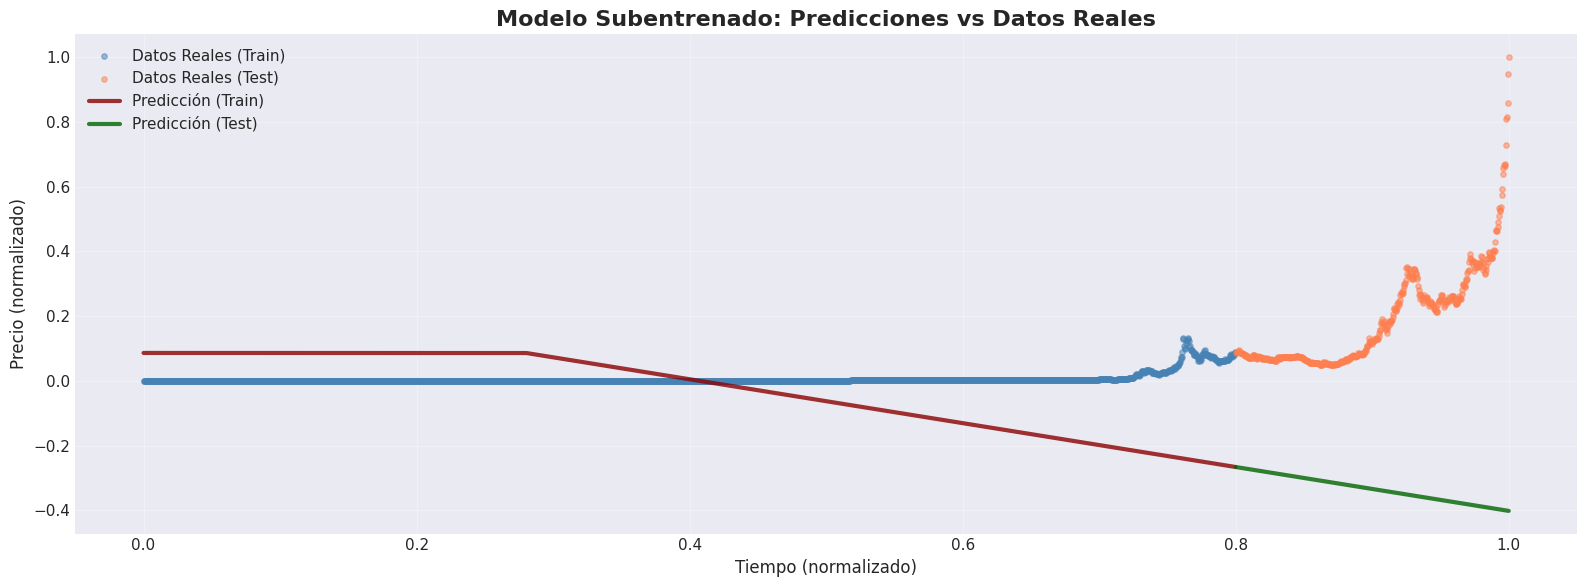

Observación: La línea de predicción es demasiado simplista y no sigue la tendencia compleja de los datos. Esto es UNDERFITTING.


In [126]:
# Gráfica de predicciones vs datos reales
plt.figure(figsize=(16, 6))

# Datos reales
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, s=15, label='Datos Reales (Train)')
plt.scatter(X_test, y_test, color='coral', alpha=0.5, s=15, label='Datos Reales (Test)')

# Predicciones
plt.plot(X_train, y_pred_under_train, color='darkred', linewidth=3, 
         label='Predicción (Train)', alpha=0.8)
plt.plot(X_test, y_pred_under_test, color='darkgreen', linewidth=3, 
         label='Predicción (Test)', alpha=0.8)

plt.title('Modelo Subentrenado: Predicciones vs Datos Reales', fontsize=16, fontweight='bold')
plt.xlabel('Tiempo (normalizado)', fontsize=12)
plt.ylabel('Precio (normalizado)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observación: La línea de predicción es demasiado simplista y no sigue la tendencia compleja de los datos. Esto es UNDERFITTING.")

# Commit 3: Modelo Sobre-entrenado (Overfitting)

## ¿Qué es el Overfitting?

El **overfitting** ocurre cuando un modelo es demasiado complejo y memoriza los datos de entrenamiento, incluyendo el ruido, perdiendo capacidad de generalización.

### Características:
- **Capacidad excesiva**: muchas capas y neuronas
- **Sobreentrenamiento**: demasiadas épocas
- **Memorización**: aprende patrones específicos del conjunto de entrenamiento
- **Baja generalización**: mal desempeño en datos nuevos
- **Divergencia**: error de entrenamiento bajo, error de validación alto

### En este ejemplo:
- Red neuronal con **4 capas** de **256, 128, 64, 32 neuronas**
- **400 epochs** de entrenamiento (excesivo)
- Sin regularización ni early stopping

In [127]:
# Crear modelo con capacidad excesiva
modelo_overfitting = Sequential([
    Dense(256, activation='relu', input_shape=(1,), name='capa_1'),
    Dense(128, activation='relu', name='capa_2'),
    Dense(64, activation='relu', name='capa_3'),
    Dense(32, activation='relu', name='capa_4'),
    Dense(1, name='capa_salida')
], name='Modelo_Overfitting')

# Compilar el modelo
modelo_overfitting.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Arquitectura del Modelo Sobreentrenado:")
modelo_overfitting.summary()
print("\n Este modelo tiene DEMASIADOS parámetros, propenso a overfitting")

Arquitectura del Modelo Sobreentrenado:


Model: "Modelo_Overfitting"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_1 (Dense)                  │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_3 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_4 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,777 (171.00 KB)

 Trainable params: 43,777 (171.00 KB)

 Non-trainable params: 0 (0.00 B)


 Este modelo tiene DEMASIADOS parámetros, propenso a overfitting


### Entrenamiento del Modelo Sobreentrenado

In [128]:
# Entrenar con muchos epochs
print("Entrenando modelo sobreentrenado (esto puede tardar un poco)...")

history_overfitting = modelo_overfitting.fit(
    X_train, y_train,
    epochs=400,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Entrenamiento completado")
print(f"\nÚltima epochs - Loss (entrenamiento): {history_overfitting.history['loss'][-1]:.6f}")
print(f"Última epochs - Loss (validación): {history_overfitting.history['val_loss'][-1]:.6f}")
print(f"\nDiferencia significativa: {abs(history_overfitting.history['loss'][-1] - history_overfitting.history['val_loss'][-1]):.6f}")

Entrenando modelo sobreentrenado (esto puede tardar un poco)...


Entrenamiento completado

Última epochs - Loss (entrenamiento): 0.000000
Última epochs - Loss (validación): 0.001500

Diferencia significativa: 0.001500


### Gráfica de Pérdida - Divergencia Train vs Validación

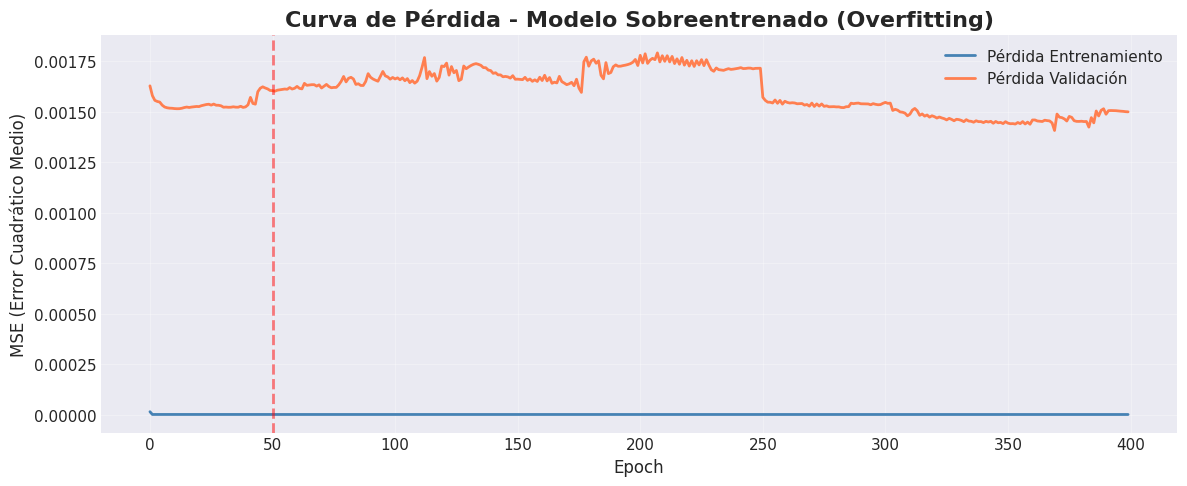

Observación: La pérdida de entrenamiento disminuye continuamente, pero la de validación comienza a aumentar. Esto es OVERFITTING.


In [129]:
# Visualizar curva de pérdida con divergencia
plt.figure(figsize=(12, 5))

plt.plot(history_overfitting.history['loss'], 
         color='steelblue', linewidth=2, label='Pérdida Entrenamiento')
plt.plot(history_overfitting.history['val_loss'], 
         color='coral', linewidth=2, label='Pérdida Validación')

plt.title('Curva de Pérdida - Modelo Sobreentrenado (Overfitting)', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE (Error Cuadrático Medio)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.5, 
            label='Inicio del overfitting')
plt.tight_layout()
plt.show()

print("Observación: La pérdida de entrenamiento disminuye continuamente, pero la de validación comienza a aumentar. Esto es OVERFITTING.")

### Predicciones y Evaluación

In [130]:
# Realizar predicciones
y_pred_over_train = modelo_overfitting.predict(X_train, verbose=0)
y_pred_over_test = modelo_overfitting.predict(X_test, verbose=0)

# Calcular métricas
mse_train_over = mean_squared_error(y_train, y_pred_over_train)
mae_train_over = mean_absolute_error(y_train, y_pred_over_train)
mse_test_over = mean_squared_error(y_test, y_pred_over_test)
mae_test_over = mean_absolute_error(y_test, y_pred_over_test)

print("Métricas del Modelo Sobreentrenado:")
print("="*50)
print(f"\nEntrenamiento:")
print(f"  - MSE: {mse_train_over:.6f}")
print(f"  - MAE: {mae_train_over:.6f}")
print(f"\nPrueba:")
print(f"  - MSE: {mse_test_over:.6f}")
print(f"  - MAE: {mae_test_over:.6f}")
print(f"\nDiferencia MSE: {abs(mse_train_over - mse_test_over):.6f}")
print("Error bajo en train pero alto en test = OVERFITTING")

Métricas del Modelo Sobreentrenado:

Entrenamiento:
  - MSE: 0.000300
  - MAE: 0.004766

Prueba:
  - MSE: 0.055081
  - MAE: 0.177944

Diferencia MSE: 0.054781
Error bajo en train pero alto en test = OVERFITTING


### Visualización de Predicciones - Memorización del Ruido

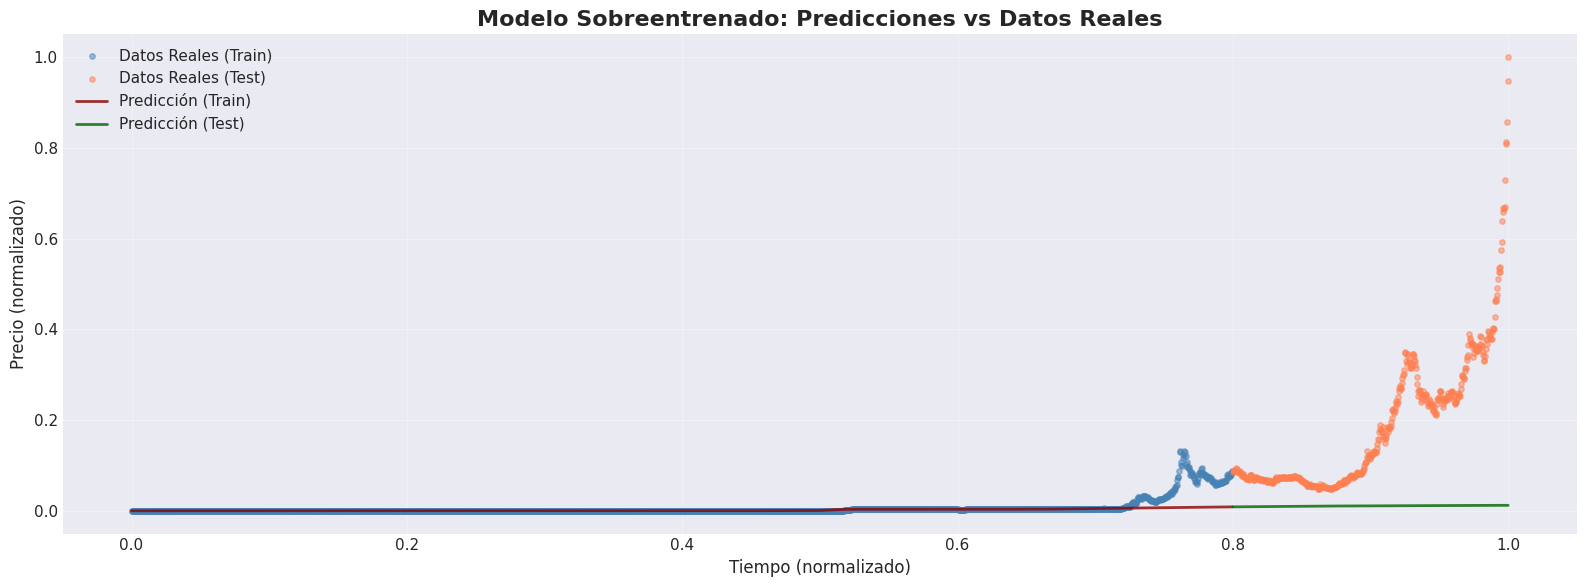

Observación: El modelo se ajusta muy bien al conjunto de entrenamiento (memoriza el ruido) pero no generaliza bien en datos de prueba.


In [131]:
# Gráfica de predicciones vs datos reales
plt.figure(figsize=(16, 6))

# Datos reales
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, s=15, label='Datos Reales (Train)')
plt.scatter(X_test, y_test, color='coral', alpha=0.5, s=15, label='Datos Reales (Test)')

# Predicciones
plt.plot(X_train, y_pred_over_train, color='darkred', linewidth=2, 
         label='Predicción (Train)', alpha=0.8)
plt.plot(X_test, y_pred_over_test, color='darkgreen', linewidth=2, 
         label='Predicción (Test)', alpha=0.8)

plt.title('Modelo Sobreentrenado: Predicciones vs Datos Reales', fontsize=16, fontweight='bold')
plt.xlabel('Tiempo (normalizado)', fontsize=12)
plt.ylabel('Precio (normalizado)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observación: El modelo se ajusta muy bien al conjunto de entrenamiento (memoriza el ruido) pero no generaliza bien en datos de prueba.")